# 第四周作业  CNN热力图练习

In [1]:
#首先执行GPU资源分配代码，勿删除。
import GPU
GPU.show()

Sat May 30 20:33:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.142                Driver Version: 580.142        CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:02:00.0 Off |                  N/A |
| 48%   54C    P2            133W /  350W |    6034MiB /  24576MiB |     33%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#选择一个空闲GPU，#0  #1  #2
GPU.alloc(0,1024)

Success.


In [3]:
import requests
url='https://img.pconline.com.cn/images/photoblog/7/4/0/8/7408028/20102/2/1265098678131_mthumb.jpg'
download=requests.get(url, allow_redirects=True)
myjpg='save/3230105908/animals.jpg'
with open(myjpg,'wb') as fp:
    fp.write(download.content)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Model
from PIL import Image
%matplotlib inline

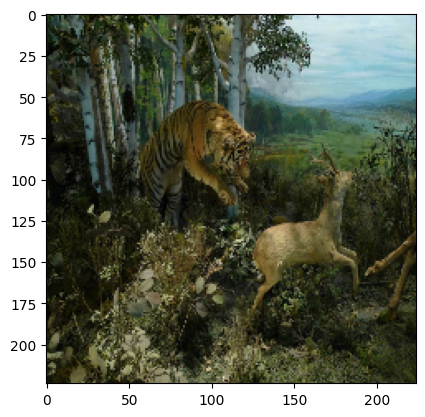

In [5]:
img = cv2.imread('save/3230105908/animals.jpg')
img = cv2.resize(img, (224,224))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [6]:
# 图像预处理
img_tensor = np.expand_dims(img, axis=0)
preprocessed_img = preprocess_input(img_tensor)

In [7]:
model = ResNet50(weights='imagenet')
print(model.summary())

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           

In [8]:
model.layers[-1].name, model.layers[-4].name

('predictions', 'conv5_block3_add')

In [9]:
# 建立两个模型，分别对应最后一层和最后卷积层的输出
ResNet_model = Model(inputs=model.input,
                    outputs=(model.layers[-4].output,model.layers[-1].output))

In [10]:
# 准备计算梯度，pred_index为预测类型，class_channel为对应输出
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = ResNet_model(preprocessed_img)
    pred_index = tf.argmax(preds[0])
    class_channel = preds[:, pred_index]

In [11]:
preds.shape, class_channel.shape

(TensorShape([1, 1000]), TensorShape([1]))

In [12]:
# 计算输出对最后卷积的梯度
grads = tape.gradient(class_channel, last_conv_layer_output)
grads.shape

TensorShape([1, 7, 7, 2048])

In [13]:
# 把梯度放在batch维和宽度、高度维度上平均，得到通道加权值
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
pooled_grads.shape

TensorShape([2048])

In [14]:
# [1,7,7,2048]去除batch维度
last_conv_layer_output1 = last_conv_layer_output[0]
# 对最后卷积层进行通道加权后累计计算
heat_map = np.dot(last_conv_layer_output1, pooled_grads)
heat_map.shape

(7, 7)

In [15]:
with open('data/imagenet_classes.txt') as fp:
    classnames = fp.readlines()
predicted_class = classnames[pred_index].strip()
print(predicted_class)

292: 'tiger, Panthera tigris',


In [16]:
heat_map = cv2.resize(heat_map, (224,224))

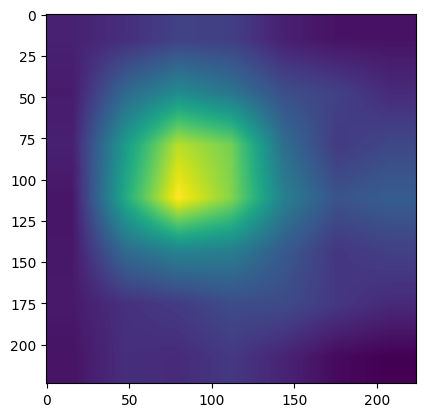

In [17]:
plt.imshow(heat_map)

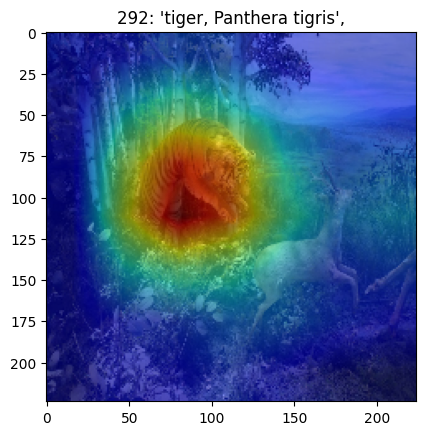

In [18]:
fig, ax = plt.subplots()
ax.imshow(img)
ax.imshow(heat_map, cmap='jet', alpha=0.5)
ax.set_title(predicted_class)
plt.show()

In [19]:
probs = preds[0].numpy()              
pred_index2 = np.argsort(probs)[-2]   

In [20]:
predicted_class = classnames[pred_index2].strip()
print(predicted_class)

282: 'tiger cat',


In [27]:
preds[0, 292], preds[0, 282]

(<tf.Tensor: shape=(), dtype=float32, numpy=0.98963225>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.008688621>)

In [22]:
with tf.GradientTape() as tape:
    last_conv_layer_output, preds = ResNet_model(preprocessed_img)
    class_channel2 = preds[:, pred_index2]

In [23]:
# 计算输出对最后卷积层的梯度
grads2 = tape.gradient(class_channel2, last_conv_layer_output)

# 把梯度在batch维和宽度、高度维上平均，得到通道加权值
pooled_grads2 = tf.reduce_mean(grads2, axis=(0,1,2))

In [24]:
# [1,7,7,2048]去除batch维度
last_conv_layer_output2 = last_conv_layer_output[0]
# 对最后卷积层进行通道加权后累积计算
heat_map2 = np.dot(last_conv_layer_output2, pooled_grads2)
heat_map2.shape

(7, 7)

In [25]:
heat_map2 = cv2.resize(heat_map2, (224, 224))

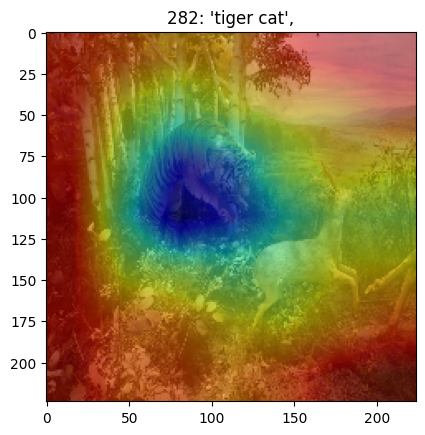

In [26]:
fig, ax = plt.subplots()
ax.imshow(img)
ax.imshow(heat_map2, cmap='jet', alpha=0.5)
ax.set_title(predicted_class)
plt.show()